In [1]:
# Aqui se cargaron las librerías necesarias.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Librerías para modelos de ciencia de datos.
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [7]:
#Se importa lectura de datos en Python y lo cargamos en la variable de Datos.
Datos = pd.read_csv('C:/Unad/Enfermedadcardíaca.csv')

In [13]:
#Aqui se realizo una lectura de datos para el aanalisis exploratorio
Datos.head(12)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


In [10]:
#Aqui muestra la descripcion de las caracteristicas de los Datos.
Datos.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


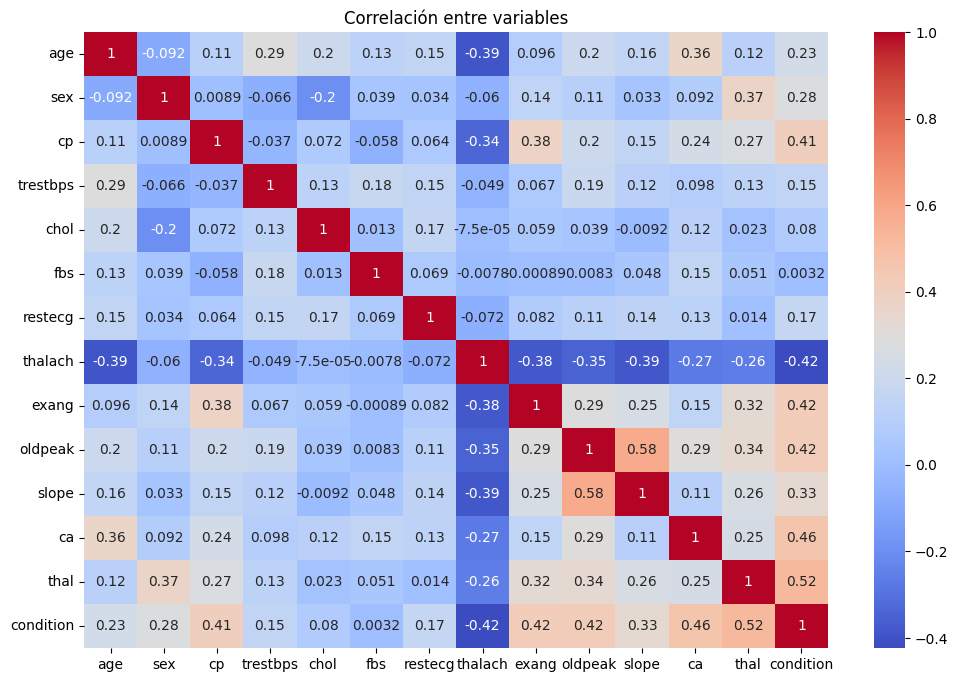

In [16]:
#Aqui se muestra la identificacion de las relaciones entre variables.
plt.figure(figsize=(12,8))
sns.heatmap(Datos.corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables')
plt.show()

Text(0.5, 1.0, 'Identificacion de los datos faltantes y Atipicos')

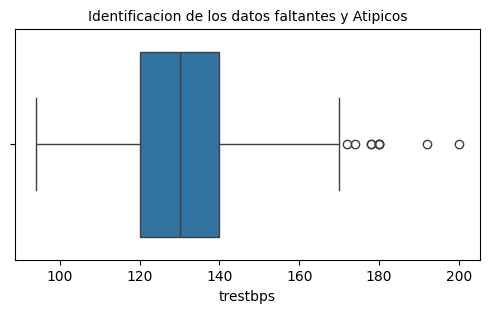

In [15]:
#Identificacion de los datos Faltantes y Atipicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['trestbps'])
plt.title('Identificacion de los datos faltantes y Atipicos', fontsize=10 )

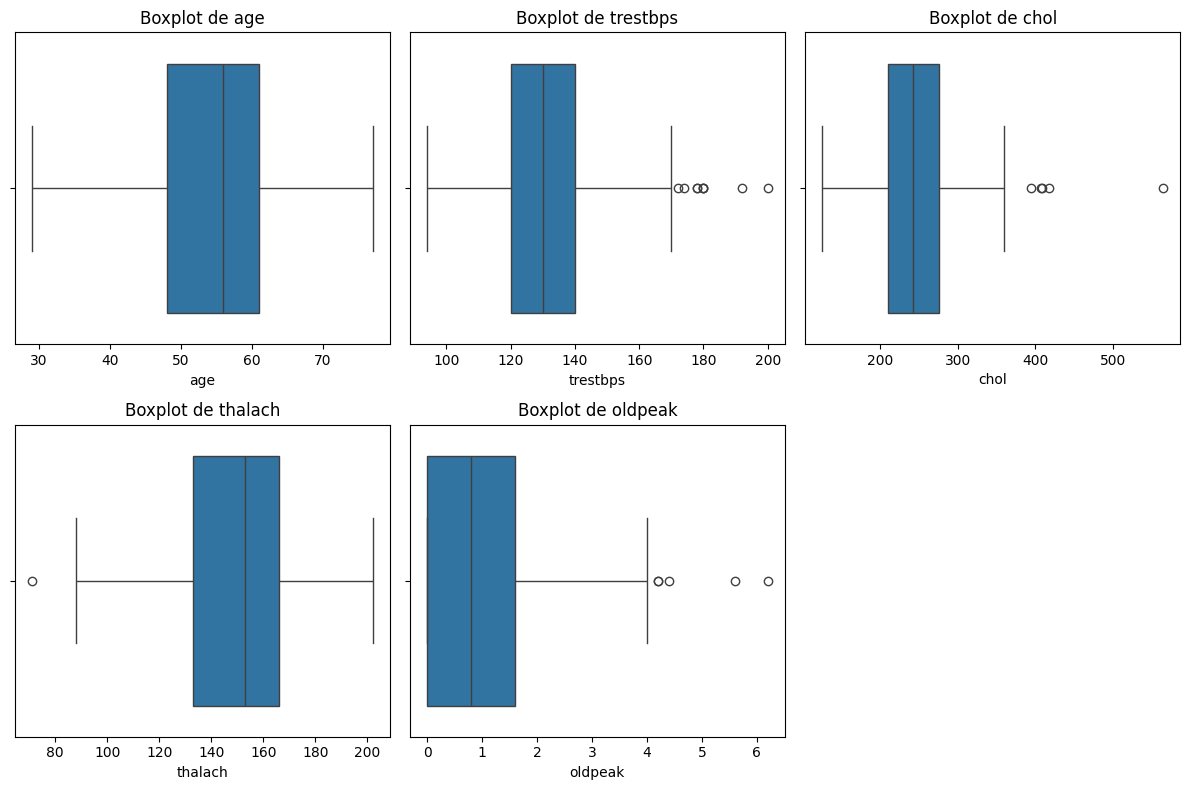

In [17]:
#Aqui se describe y se muestran la Identificación de los datos atípicos.

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(12,8))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=Datos[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


In [18]:
#Conclusión del punto #1
#No hay datos faltantes según el conteo.
#Datos atípicos detectados visualmente en chol y oldpeak, posiblemente también en trestbps.

In [3]:
#paso2: Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario.

# Verificar valores faltantes
print("Valores nulos por columna:")
print(Datos.isnull().sum())

# Convertir columnas categóricas a tipo category
categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categoricas:
    Datos[col] = Datos[col].astype('category')

# Escalar variables numéricas
numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
escalador = StandardScaler()
Datos[numericas] = escalador.fit_transform(Datos[numericas])

# Verificación final
print(Datos.dtypes)


Valores nulos por columna:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64
age           float64
sex          category
cp           category
trestbps      float64
chol          float64
fbs          category
restecg      category
thalach       float64
exang        category
oldpeak       float64
slope        category
ca           category
thal         category
condition       int64
dtype: object


In [19]:
# Paso 3: Selección de características más relevantes (con f_classif, compatible con valores negativos)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)  # Seleccionamos las 10 mejores variables
X_seleccionadas = selector.fit_transform(X_dummies, y)

# Mostrar nombres de columnas seleccionadas
columnas_seleccionadas = X_dummies.columns[selector.get_support()]
print("Características seleccionadas:")
print(columnas_seleccionadas)


Características seleccionadas:
Index(['thalach', 'oldpeak', 'sex_1', 'cp_1', 'cp_2', 'cp_3', 'exang_1',
       'slope_1', 'ca_2', 'thal_2'],
      dtype='object')


In [20]:
# Paso 4: Dividir el dataset en Train y Test para evaluar correctamente el modelo.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_dummies[columnas_seleccionadas], y, test_size=0.3, random_state=42)

In [29]:
print(X_train)

      thalach   oldpeak  sex_1   cp_1   cp_2   cp_3  exang_1  slope_1   ca_2  \
266  0.585108 -0.906712  False  False  False   True    False    False  False   
37   0.148482  0.209975  False   True  False  False    False     True  False   
16   1.240047  0.124076   True  False  False  False    False     True  False   
253  0.454120 -0.906712  False  False  False   True    False    False  False   
144  1.938648 -0.219520   True  False   True  False    False    False  False   
..        ...       ...    ...    ...    ...    ...      ...      ...    ...   
188  0.323132  0.124076  False  False  False   True    False     True  False   
71   2.287949 -0.906712   True   True  False  False    False    False  False   
106 -0.331806 -0.391318   True  False   True  False     True     True  False   
270 -1.379708 -0.047722   True  False  False   True     True     True  False   
102  0.672433 -0.906712   True  False   True  False    False    False  False   

     thal_2  
266   False  
37    False

In [30]:
print(X_test)

      thalach   oldpeak  sex_1   cp_1   cp_2   cp_3  exang_1  slope_1   ca_2  \
167  0.672433 -0.047722  False  False  False   True     True     True   True   
211  0.541445 -0.906712   True  False  False   True     True    False  False   
63  -0.768432 -0.906712   True   True  False  False    False     True  False   
154  0.890746 -0.906712  False  False   True  False    False    False  False   
5    0.235807 -0.391318   True  False  False  False    False     True  False   
..        ...       ...    ...    ...    ...    ...      ...      ...    ...   
15   1.763998 -0.906712   True  False  False  False    False     True  False   
10   0.410458 -0.734914   True  False  False  False    False     True  False   
228 -0.288144  1.670258   True  False  False   True     True     True  False   
184 -0.244481  2.529248   True  False  False   True     True    False   True   
68   1.414697 -0.906712   True   True  False  False    False    False  False   

     thal_2  
167    True  
211    True

In [22]:
# Paso 5: Entrenar el modelo configurando los diferentes hiperparámetros

from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [31]:
X_test.head(10)

,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,exang_1,slope_1,ca_2,thal_2
167,0.672433,-0.047722,False,False,False,True,True,True,True,True
211,0.541445,-0.906712,True,False,False,True,True,False,False,True
63,-0.768432,-0.906712,True,True,False,False,False,True,False,False
154,0.890746,-0.906712,False,False,True,False,False,False,False,False
5,0.235807,-0.391318,True,False,False,False,False,True,False,True
77,-1.510696,0.381773,False,False,True,False,False,True,False,False
183,-0.768432,0.639470,True,False,False,True,True,False,False,True
158,-1.772671,1.154864,True,False,False,True,False,True,False,False
9,-0.200818,2.701046,True,False,False,False,False,False,False,True
139,1.283709,-0.563116,True,False,True,False,True,False,False,False


In [33]:
Prediccion = modelo.predict(X_test)

In [34]:
print(Prediccion)

[1 1 0 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1
 0 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0]


In [23]:
# Paso 6:Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = modelo.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Matriz de confusión:
[[39  9]
 [ 8 34]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        48
           1       0.79      0.81      0.80        42

    accuracy                           0.81        90
   macro avg       0.81      0.81      0.81        90
weighted avg       0.81      0.81      0.81        90



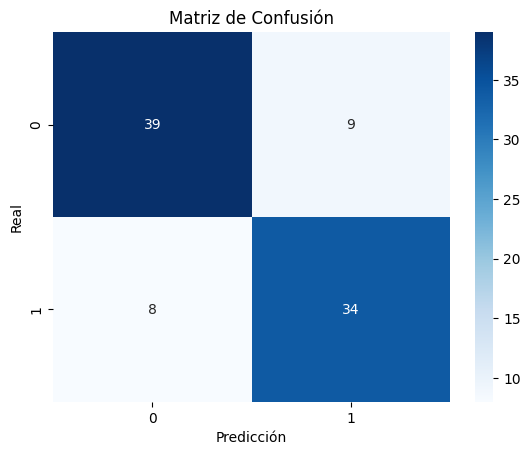

In [27]:
# Paso 7:Realizar las diferentes gráficas que permitan visualizar los resultados del modelo
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


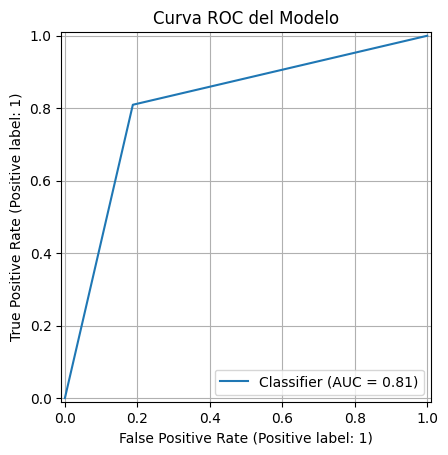

In [37]:
# Curva de precision del modelo
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Curva ROC del modelo
RocCurveDisplay.from_predictions(y_test, Prediccion)
plt.title('Curva ROC del Modelo')
plt.grid()
plt.show()